# Sign Language Gesture Recognition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.decomposition import PCA

train_df = pd.read_csv('sign_mnist_train.csv')
test_df = pd.read_csv('sign_mnist_test.csv')

print(f"Training rows: {train_df.shape[0]}, Features: {train_df.shape[1]-1}")
train_df.head()

c:\Users\raees\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\raees\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Training rows: 27455, Features: 784


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


- Each row represents a 28x28 grayscale image flattened into 784 pixel columns (0-255).
- The label column contains the target classes 

C:\Users\raees\AppData\Local\Temp\ipykernel_29632\3456176949.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df['label'], palette='viridis')


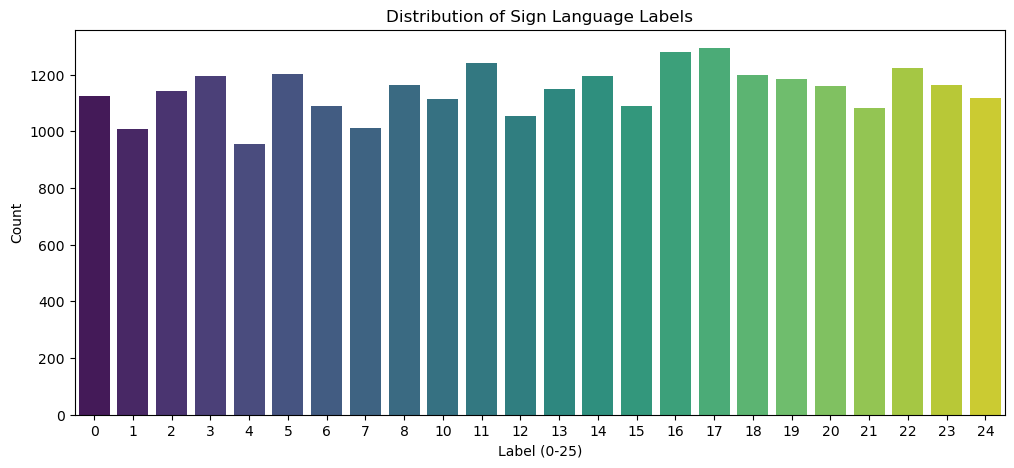

Unique labels in dataset: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [2]:
# class balancing and label inspection 

plt.figure(figsize=(12,5))
sns.countplot(x=train_df['label'], palette='viridis')
plt.title("Distribution of Sign Language Labels")
plt.xlabel("Label (0-25)")
plt.ylabel("Count")
plt.show()

# Identifying missing letters
unique_labels = sorted(train_df['label'].unique())
print(f"Unique labels in dataset: {unique_labels}")

Sign Language MNIST is relatively balanced, but it is important to note that labels 9 (J) and 25 (Z) are absent because they require motion, which cannot be captured in a single static image.

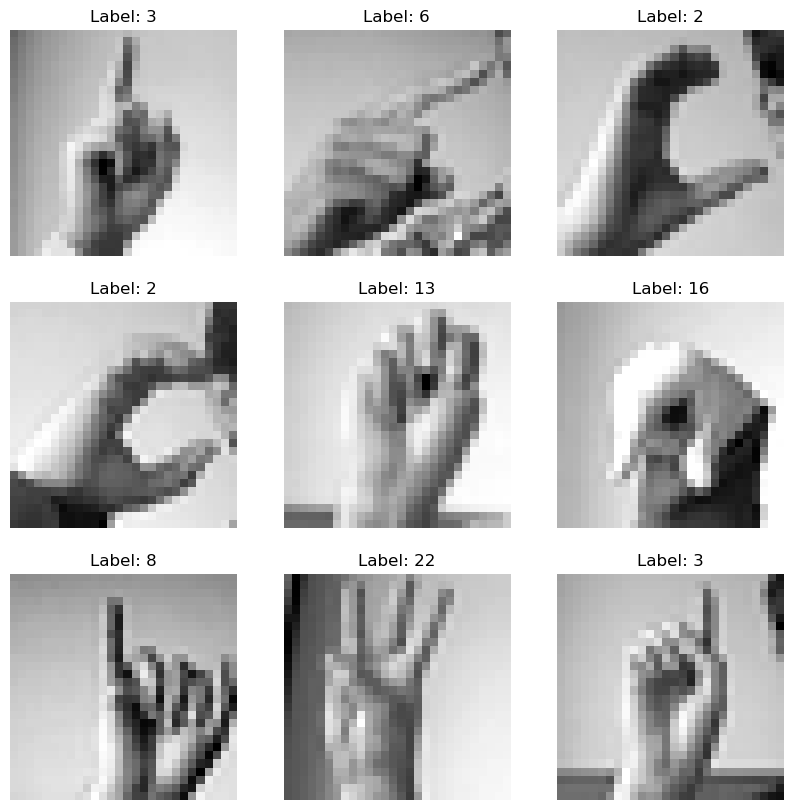

In [3]:
# visualise the data 

images = train_df.drop('label', axis=1).values
labels = train_df['label'].values

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')
plt.show()

We reshape the flat 1D pixel arrays (784 columns) back into 2D matrices ($28 \times 28$). This confirms that the data is correctly structured and allows us to verify the hand shapes visually.

In [4]:
# standardise the data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(images)

Total Explained Variance (50 components): 0.8874


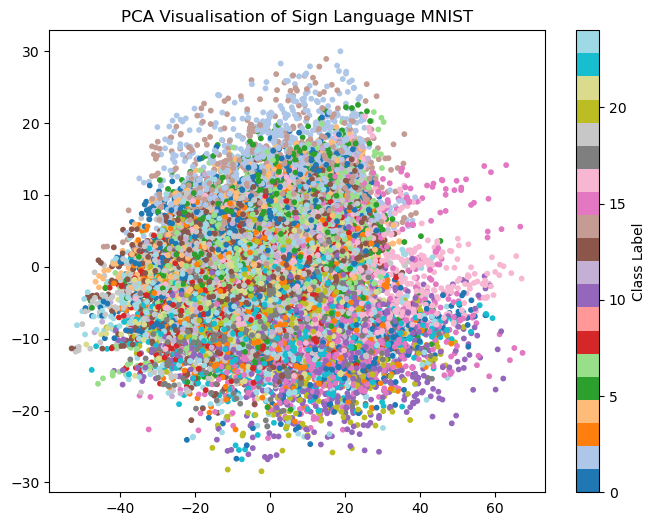

In [6]:
# PCA for dimensionality reduction and visualisation

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"Total Explained Variance (50 components): {explained_variance:.4f}")

pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=labels, cmap='tab20', s=10)
plt.colorbar(label='Class Label')
plt.title("PCA Visualisation of Sign Language MNIST")
plt.show()

We reduce the 784-dimensional space into 50 principal components. This captures approximately 88.74% of the total variance. The 2D scatter plot reveals that while some clusters are distinct, there is significant overlap between certain gestures. This mathematical observation justifies the move toward more complex non-linear models like Deep Neural Networks.

In [7]:
from sklearn.model_selection import train_test_split

# Pixel Normalization (Scaling to 0-1)
X_train_full = images / 255.0
X_test_final = test_df.drop('label', axis=1).values / 255.0

# Reshaping for CNN & RNN Architectures
X_train_cnn = X_train_full.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_final.reshape(-1, 28, 28, 1)

# One-Hot Encoding
lb = LabelBinarizer()
y_train_full = lb.fit_transform(labels)
y_test_final = lb.transform(test_df['label'])

# 4. Train-Validation Split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_cnn, y_train_full, test_size=0.2, random_state=42
)

print(f"Final Preprocessed Training Shape: {X_train.shape}")

Final Preprocessed Training Shape: (21964, 28, 28, 1)


We normalize pixel values to a $[0, 1]$ range to improve gradient descent stability. We reshape the data into 4D tensors for the CNN-based models and apply One-Hot Encoding to the labels. Finally, we split the data into training and validation sets to monitor for overfitting during the experimental phase.